In [2]:
import pandas as pd
# Load the dataset into a variable named 'df'
df = pd.read_csv('retail_sales_dataset.csv')

# show the first 5 rows of the data
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
# 1. Check data types and see if there are any missing (null) values
print("--- Data Information ---")
df.info()

# 2. Check for duplicate rows
print("\n--- Number of Duplicate Rows ---")
print(df.duplicated().sum())

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

--- Number of Duplicate Rows ---
0


In [4]:
# 1. Change the 'Date' column from text to a real Date format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Get the basic descriptive statistics for numerical columns
print("--- Mathematical Summary ---")
df.describe()

--- Mathematical Summary ---


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


--- Total Sales by Category ---
  Product Category  Total Amount
0           Beauty        143515
1         Clothing        155580
2      Electronics        156905


/tmp/ipykernel_1375/1892434728.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y= 'Total Amount', data=category_sales, palette='viridis')


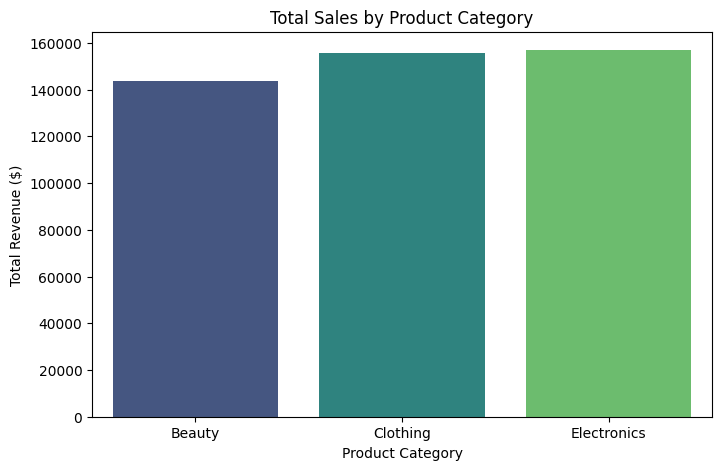

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group data by Product Category and calculate total sales
category_sales = df.groupby('Product Category')['Total Amount'].sum().reset_index()
print("--- Total Sales by Category ---")
print(category_sales)

# 2. Create a Bar Plot for visualization
plt.figure(figsize = (8, 5))
sns.barplot(x='Product Category', y= 'Total Amount', data=category_sales, palette='viridis')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue ($)')
plt.show()

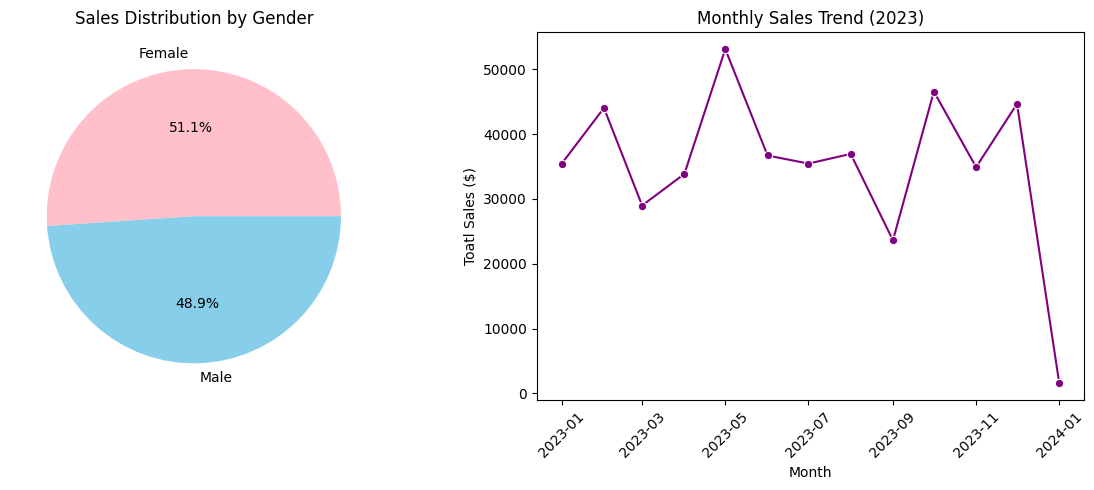

In [6]:
# 1. Customer Analysis: Total Sales by Gender
gender_sales = df.groupby('Gender')['Total Amount'].sum().reset_index()

plt.figure(figsize=(12, 5))

# Create Gender Pie Chart
plt.subplot(1, 2, 1)
plt.pie(gender_sales['Total Amount'], labels=gender_sales['Gender'], autopct='%1.1f%%', colors=['pink', 'skyblue'])
plt.title('Sales Distribution by Gender')

# 2. Time Series Analysis: Monthly Sales Trend
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()

# Create Monthly Line Chart
plt.subplot(1, 2, 2)
sns.lineplot(x = 'Month', y= 'Total Amount', data=monthly_sales, marker='o', color='purple')
plt.title('Monthly Sales Trend (2023)')
plt.xlabel('Month')
plt.ylabel('Toatl Sales ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()